In this notebook, we analyze the results from our adversarial 2048 simulations and compare the different algorithms used: minimax, expectimax, and Monte Carlo tree search.

In [15]:
from pandas import DataFrame
import seaborn as sns
from data_analysis import read_minimax_vs_random_data, read_minimax_vs_adversary_data, make_cat_plots

In [16]:
df: DataFrame = read_minimax_vs_random_data()
print(df.columns)
df.describe()

Index(['score', 'turns_taken', 'execution_time', 'largest_tile', 'depth'], dtype='str')


,score,turns_taken,execution_time,largest_tile,depth
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,4582.441600,666.326400,22.620906,384.614400,3.000000
std,2095.610181,230.075393,57.261217,176.525771,1.414496
min,556.000000,148.000000,0.010630,64.000000,1.000000
25%,3072.000000,502.000000,0.095292,256.000000,2.000000
50%,3832.000000,614.000000,0.318798,256.000000,3.000000
75%,6292.000000,844.500000,15.476893,512.000000,4.000000
max,15392.000000,1778.000000,401.687982,1024.000000,5.000000


What was the best search depth? Let's look at the graphs of how the mean scores improved as we increased the search depth

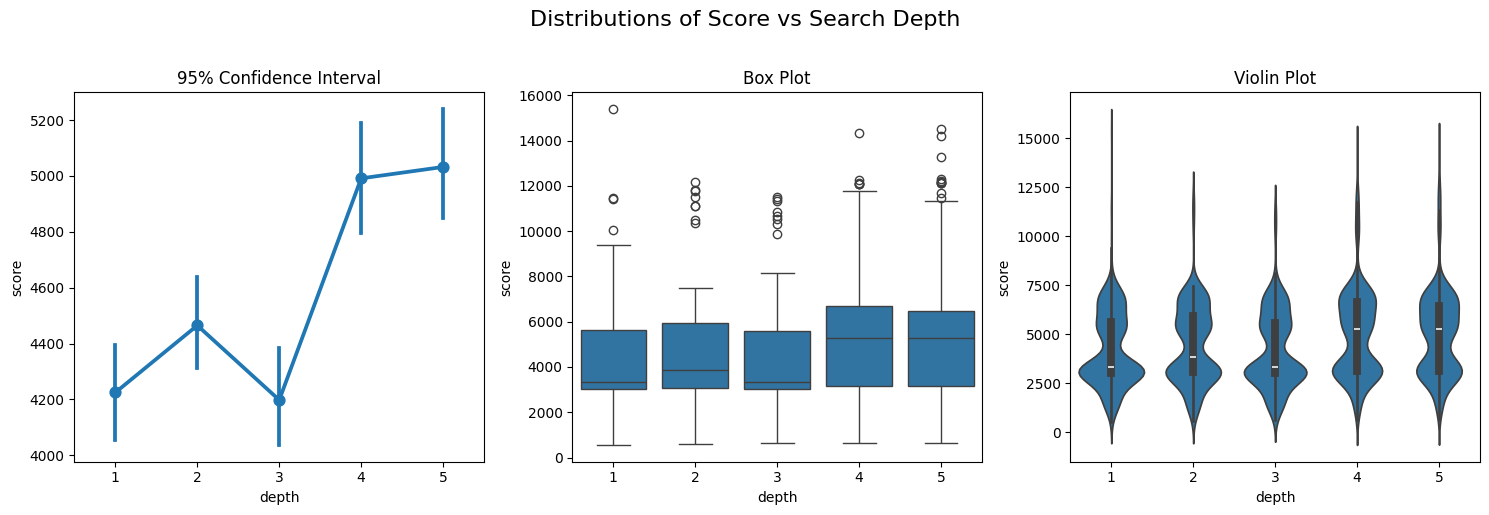

In [17]:
make_cat_plots(data=df, x="depth", y="score", title="Distributions of Score vs Search Depth", ci=95)

For both the minimax being player one or two, it seems like there is a general upward trend as the search depth increases. For the simulated matches against adversaries other than a random adversary, we will be using a search depth of 5 for the sake of computation time.

Note: The high concentration around a score of 3000 in depths of 1-3 can be attributed to the "256 wall." Once the algorithms can pass this wall (like on depth 4 or greater), they are able to get much greater scores.

In [18]:
df.groupby('depth')['score'].mean()

depth
1    4225.096
2    4465.152
3    4198.144
4    4991.512
5    5032.304
Name: score, dtype: float64

Now, we can compare minimax's performance against various adversaries with a depth of 5.

In [19]:
minimax_df: DataFrame = read_minimax_vs_adversary_data()
print(minimax_df.columns)
minimax_df.describe()

Index(['score', 'turns_taken', 'execution_time', 'largest_tile', 'adversary',
       'monte_carlo_depth', 'rollout', 'depth'],
      dtype='str')


,score,turns_taken,execution_time,largest_tile,monte_carlo_depth,rollout,depth
count,2000.000000,2000.000000,2000.000000,2000.000000,500.0,500.0,2000.0
mean,1939.374000,343.534000,57.229174,163.424000,12.0,20.0,5.0
std,2121.348966,249.756417,70.919062,177.592651,0.0,0.0,0.0
min,288.000000,104.000000,7.257880,32.000000,12.0,20.0,5.0
25%,716.000000,192.000000,16.398028,64.000000,12.0,20.0,5.0
50%,988.000000,234.000000,35.179375,64.000000,12.0,20.0,5.0
75%,1826.000000,358.500000,53.072247,128.000000,12.0,20.0,5.0
max,14516.000000,1698.000000,401.687982,1024.000000,12.0,20.0,5.0


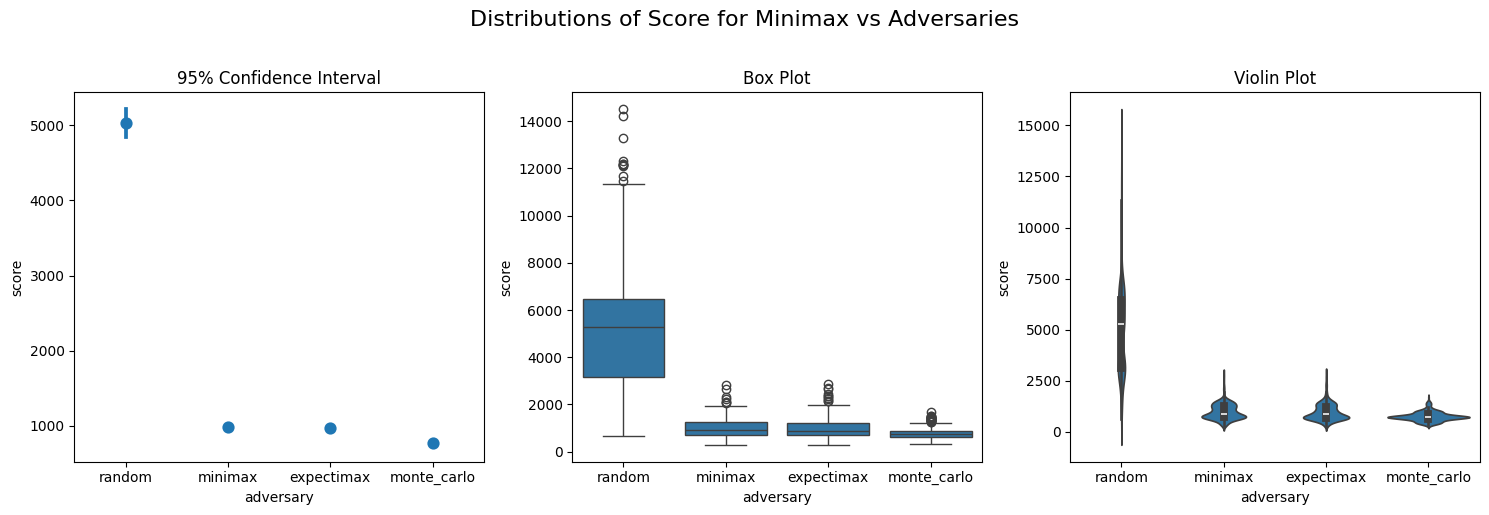

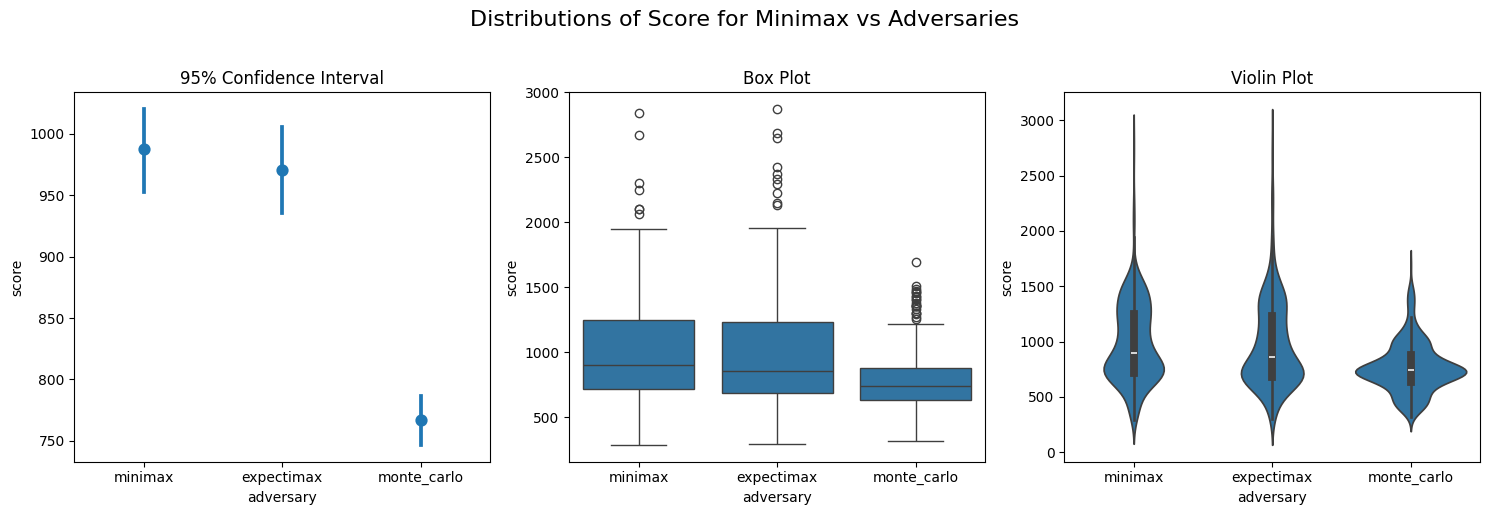

In [23]:
# Compare average scores for each adversary
make_cat_plots(
    data=minimax_df,
    x="adversary",
    y="score",
    title="Distributions of Score for Minimax vs Adversaries",
    linestyles="",
    ci=95
)

make_cat_plots(
    data=minimax_df[~(minimax_df["adversary"] == "random")],
    x="adversary",
    y="score",
    title="Distributions of Score for Minimax vs Adversaries",
    linestyles="",
    ci=95
)
